# UK road‑crash severity & deprivation — a resource‑prioritisation analysis
*Warwick WBS · IB94V0 Data Analytics & AI · individual project*

## 0. How to Run This Notebook
This notebook runs **top‑to‑bottom** (`Kernel → Restart & Run All`); seeds are fixed and paths are relative. Expected folder layout:

```text
project_folder/
  road_safety_severity_analysis.ipynb
  data/
    Road Accident Data.csv
    File_10_-_IoD2019_Local_Authority_District_Summaries__lower-tier__.xlsx
    local_authority_traffic.csv
    LAD17_CTYUA17_EW_LU.csv
    dft-road-casualty-statistics-collision-1979-latest-published-year.csv   # (or the bundled 2015–24 subset)
    File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3.csv
  outputs/        # charts/tables are written here (auto-created)
  requirements.txt
  README.txt
```
- Put all data files in **`data/`** (sources & dictionary in §2). Charts save to **`outputs/`**.
- Install deps: `pip install -r requirements.txt` (Python ≥ 3.10). Package versions are printed in §16.

## 1. Business Problem and Decision Context
**Problem.** A **regional road‑safety / public‑health team** needs to prioritise limited **KSI‑prevention** resources by identifying the road *contexts* and *areas* where collisions are more likely to become **serious or fatal**, and where the **absolute KSI burden per vehicle‑mile** is highest. / 在有限预算下,识别"哪些道路情境与地区的车祸更易致重伤/致命、且每车英里 KSI 负担最高",据此优先投放预防资源。

- **Decision‑maker:** local authority / regional road‑safety team / transport‑safety planners.
- **Decision:** *where* and *what* to prioritise for road‑safety interventions.
- **Model use:** a **triage / ranking / resource‑prioritisation** signal.
- **Model NON‑use:** **not** a real‑time individual‑crash predictor or an automated enforcement system. Many fields (weather, light, surface, vehicle type) are known only *at/after* the collision, so this is a **retrospective risk‑context analysis**, not pre‑crash prediction.
- **Cost asymmetry:** flagging a context that turns out severe (and acting) prevents a death/serious injury — far more valuable than attention on a low‑risk context.

**Value hook.** Because serious and fatal collisions impose large social and budgetary costs, even a *moderate* ranking tool can be valuable if it helps safety teams focus engineering reviews on the highest‑risk road contexts (an illustrative figure is in §14). / 重伤/致命车祸的社会与财政代价巨大,即便一个中等的排序工具,只要能帮团队把工程审查聚焦到最高风险情境,也有价值(示例金额见 §14)。

**Research questions (aligned to the sections below):**
1. Can road‑context features provide a **useful severity triage signal**? (§8–§10)
2. Which **road/environment conditions** are associated with severity? (§11)
3. How does the **KSI burden differ across deprivation once exposure is considered**? (§12)

## 2. Data Sources and Data Dictionary
| Source | Contributes | Join key | Relevance | Scope limit |
|---|---|---|---|---|
| **Kaggle `xavierberge/road-accident-dataset`** (GB collisions 2021–22, ~308k×23) | the analysis base + target | — | the collisions to characterise | STATS19‑style extract (see §13 provenance note) |
| **English IMD 2019 — File_10 (LAD)** | area deprivation score | LAD name | the equity question | **England‑only** |
| **DfT local‑authority traffic / vehicle‑miles** | exposure denominator | LA (ONS code) | absolute KSI **burden per mile** | motor‑vehicle exposure only |
| **ONS LAD17→UTLA/county lookup** | maps districts → traffic geography | LAD code | makes the traffic join valid | 2017 boundaries |
| **Official DfT STATS19 collisions 2015–2024** | multi‑year robustness | ONS district / LSOA | tests COVID‑artefact doubt | coded; severity‑reporting change (§13) |
| **IMD 2019 — File_7 (LSOA)** | fine‑grained deprivation | LSOA code | reduces (not eliminates) ecological‑fallacy concern | England‑only |

**Data dictionary (main variables):**
| Variable | Meaning |
|---|---|
| `KSI` | target: 1 = Killed‑or‑Seriously‑Injured, 0 = Slight (from `Accident_Severity`) |
| `Accident_Severity` | Fatal / Serious / Slight (target source — excluded as a feature) |
| `Speed_limit` | road speed limit (mph) |
| `Hour` | hour of day (0–23), parsed from `Time` |
| `Urban_or_Rural_Area` | urban vs rural setting |
| `Light_Conditions` | daylight / darkness + lighting |
| `Road_Type` | single/dual carriageway, roundabout, slip, etc. |
| `Weather_Conditions` | fine / rain / snow / fog … (at‑scene) |
| `Vehicle_Type` | vehicle category involved |
| `Local_Authority_(District)` | district name — join key to IMD/traffic |
| IMD score (`IMD - Average score`) | area deprivation (audit/stratification variable, **not** a model feature) |
| vehicle‑miles (`all_motor_vehicles`) | traffic exposure denominator for KSI‑per‑mile |

**Provenance note (STATS19 subset).** `stats19_collisions_2015_2024_subset.csv` is a **column‑reduced extract** from the official DfT STATS19 collision file — England, **2015–2024**, keeping only the four variables the robustness checks need (`collision_year`, `collision_severity`, `local_authority_ons_district`, `lsoa_of_accident_location`). **It is not sampled** (every collision in range is retained), so §13 legitimately reflects the *official* data, not a sub‑sample. The full official file is used automatically under the same filename logic if present (one‑line extract code in README). / 该子集是官方 STATS19 的**列裁剪**抽取(英格兰 2015–2024,仅 4 个所需列),**非抽样**(范围内全量保留),故 §13 反映官方数据;有全量则自动改用。

## 3. Data Loading and Reproducibility Setup
**Why centralised / relative / seeded:** one place for imports, the fixed seed, the (relative) paths and filename constants makes the notebook reproducible and auditable; a file‑existence check fails fast with a helpful message. `Accident_Index` is read as **text** because Excel corrupted it to scientific notation (§4).

In [1]:
# --- imports (all used below) ---
import warnings, sys
import numpy as np, pandas as pd, re
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GroupKFold, cross_val_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, recall_score, precision_score, silhouette_score)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import spearmanr
import shap

# --- reproducibility + clean output ---
RANDOM_STATE = 42; np.random.seed(RANDOM_STATE)
N_JOBS = 1                                            # single-process: deterministic, no multiprocessing/resource_tracker noise
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60); sns.set_theme(style="whitegrid")

# --- relative paths (no machine-specific absolute paths) ---
BASE   = Path(".")
DATA   = BASE / "data"
OUTPUT = BASE / "outputs"; OUTPUT.mkdir(exist_ok=True)

# --- filename constants (managed in one place) ---
F_ACCIDENTS   = "Road Accident Data.csv"
F_IMD_LAD     = "File_10_-_IoD2019_Local_Authority_District_Summaries__lower-tier__.xlsx"
F_TRAFFIC     = "local_authority_traffic.csv"
F_LAD2CTY     = "LAD17_CTYUA17_EW_LU.csv"
F_IMD_LSOA    = "File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3.csv"
F_STATS19_FULL= "dft-road-casualty-statistics-collision-1979-latest-published-year.csv"
F_STATS19_SUB = "stats19_collisions_2015_2024_subset.csv"
STATS19 = F_STATS19_FULL if (DATA/F_STATS19_FULL).exists() else F_STATS19_SUB   # full if present, else bundled subset

# --- fail fast with a helpful message if inputs are missing ---
need = [F_ACCIDENTS, F_IMD_LAD, F_TRAFFIC, F_LAD2CTY, F_IMD_LSOA]
missing = [f for f in need if not (DATA/f).exists()] + ([] if (DATA/STATS19).exists() else ["a STATS19 collision file (full or subset)"])
assert not missing, "Missing in ./data/: " + "; ".join(missing) + "  — see §0 'How to Run'."
print("environment OK | python", sys.version.split()[0], "| using STATS19:", STATS19)

# --- load primary dataset; target KSI (Killed or Seriously Injured) ---
acc = pd.read_csv(DATA/F_ACCIDENTS, encoding="utf-8-sig", dtype={"Accident_Index":str}, low_memory=False)
acc["KSI"] = acc["Accident_Severity"].isin(["Serious","Fatal"]).astype(int)
print("accident data:", acc.shape)

environment OK | python 3.13.5 | using STATS19: stats19_collisions_2015_2024_subset.csv


accident data: (307973, 24)


## 4. Data Quality Checks
*Diagnostics only (cleaning is §5). Includes the "is this data real?" sanity check, the IMD join coverage waterfall, and a quality summary table.*

In [2]:
acc["_date"]=pd.to_datetime(acc["Accident Date"], errors="coerce", dayfirst=True)
idx_top=acc["Accident_Index"].value_counts().iloc[0]
print("dtypes (sample):", dict(list(acc.dtypes.astype(str).items())[:6]))
print("target distribution:", acc.Accident_Severity.value_counts().to_dict())
print("date parse failures:", f"{acc._date.isna().mean():.0%}", "-> use integer Year instead")
print("\n4.1 Is this data real? univariate AUC -> KSI (≈0.5 = no trivial separator; synthetic sets show 0.8–0.95):")
for c in ["Speed_limit","Latitude","Longitude"]:
    a=roc_auc_score(acc.KSI, acc[c].fillna(acc[c].median())); print(f"   {c:11s} {max(a,1-a):.3f}")
dq=pd.DataFrame({"check":["rows","columns (source)","year range","whole-row duplicates",
   "Accident_Index corrupted to one value","KSI positive rate","missing Weather_Conditions",
   "missing Road_Type","speed_limit range (mph)","GB lat/long bounds"],
  "value":[f"{len(acc):,}","23",f"{int(acc.Year.min())}–{int(acc.Year.max())}",int(acc.duplicated().sum()),
   f"{idx_top:,} ({idx_top/len(acc):.0%})",f"{acc.KSI.mean():.3f}",f"{acc.Weather_Conditions.isna().mean():.1%}",
   f"{acc.Road_Type.isna().mean():.1%}",f"{int(acc.Speed_limit.min())}–{int(acc.Speed_limit.max())}",
   f"lat {acc.Latitude.min():.1f}–{acc.Latitude.max():.1f}, lng {acc.Longitude.min():.1f}–{acc.Longitude.max():.1f}"]})
print("\nData quality summary:\n", dq.to_string(index=False))

dtypes (sample): {'Accident_Index': 'object', 'Accident Date': 'object', 'Month': 'object', 'Day_of_Week': 'object', 'Year': 'int64', 'Junction_Control': 'object'}
target distribution: {'Slight': 263280, 'Serious': 40740, 'Fatal': 3953}
date parse failures: 60% -> use integer Year instead

4.1 Is this data real? univariate AUC -> KSI (≈0.5 = no trivial separator; synthetic sets show 0.8–0.95):
   Speed_limit 0.547
   Latitude    0.513
   Longitude   0.500



Data quality summary:
                                 check                       value
                                 rows                     307,973
                     columns (source)                          23
                           year range                   2021–2022
                 whole-row duplicates                           1
Accident_Index corrupted to one value               110,304 (36%)
                    KSI positive rate                       0.145
           missing Weather_Conditions                        2.0%
                    missing Road_Type                        0.5%
              speed_limit range (mph)                       10–70
                   GB lat/long bounds lat 49.9–60.6, lng -7.5–1.8


In [3]:
# IMD join coverage waterfall + matched-vs-unmatched audit (deprivation source: §2)
imd=pd.read_excel(DATA/F_IMD_LAD, sheet_name="IMD"); imd.columns=[c.strip() for c in imd.columns]
IMD_SCORE="IMD - Average score"
def norm(s):
    s=str(s).lower().strip().replace("&","and")
    s=re.sub(r",?\s*(city of|county of|royal borough of|london borough of)\b","",s)
    return re.sub(r"\s+"," ",re.sub(r"[^a-z0-9 ]","",s)).strip()
acc["_lad"]=acc["Local_Authority_(District)"].map(norm); imd["_lad"]=imd["Local Authority District name (2019)"].map(norm)
acc=acc.merge(imd.set_index("_lad")[[IMD_SCORE]], left_on="_lad", right_index=True, how="left")
nt=len(acc); ne=acc[IMD_SCORE].notna().sum()
print(f"IMD coverage waterfall: total {nt:,} -> England-matched {ne:,} ({ne/nt:.1%}) -> unmatched {nt-ne:,} ({1-ne/nt:.1%})")
acc["_m"]=acc[IMD_SCORE].notna()
print("matched vs unmatched audit:\n", acc.groupby("_m").agg(n=("KSI","size"),ksi_rate=("KSI","mean"),mean_speed=("Speed_limit","mean")).round(3).to_string())

IMD coverage waterfall: total 307,973 -> England-matched 271,876 (88.3%) -> unmatched 36,097 (11.7%)
matched vs unmatched audit:
             n  ksi_rate  mean_speed
_m                                 
False   36097     0.163      42.050
True   271876     0.143      38.443


📊 **Read‑out:** ~**308k** real GB collisions (2021–22), **KSI 14.5%**, only **1** whole‑row duplicate, valid GB geo and the exact DfT speed ladder → genuinely collected data (every univariate AUC 0.50–0.55, no trivial separator). One red flag: **`Accident_Index` is 36% corrupted** (Excel `2.01E+12`) → never used as a key. IMD join covers **88.3%** (England‑only); the dropped 11.7% (Scotland/Wales + rural) skews slightly faster/higher‑KSI, so deprivation results are **England, district‑level**. **→ These checks set the modelling scope:** proceed on **England‑matched** records, **exclude** the corrupted `Accident_Index` and the unreliable free‑text `Accident Date`, and frame the project as an **England district‑level resource‑prioritisation** analysis — leading into §5 cleaning and §6 leakage control. / 真实大样本;损坏ID不当键;IMD 覆盖 88.3%。这些检查决定建模范围:用 England‑matched、弃损坏ID与不可靠日期、定位为英格兰区级资源优先级分析 → 引出 §5/§6。

## 5. Data Cleaning and Pre‑processing
Each step: **issue → treatment → rationale → effect**.
- **Sentinel codes** ("unknown / data missing / out of range") → set to NaN, then **retained as an explicit missing indicator via dummy encoding** (`dummy_na=True`). *Rationale:* this avoids treating "unknown" as a *normal road category*, but it does **not** fully prevent the model from using missingness — so §13 explicitly tests whether the model relies on it (dropping `Junction_Control` moves AUC by only 0.001). *Effect:* measured missingness rises honestly (e.g. `Junction_Control` ~30%).
- **Key features missing** (`Speed_limit`, `Road_Type`, `Urban_or_Rural_Area`) → drop those rows. *Rationale:* core context must be present. *Effect:* small loss.
- **England‑matched restriction** (IMD non‑null) → keep England rows. *Rationale:* model and equity audit must describe **one** population.
- **De‑duplicate on whole rows** (never the corrupted `Accident_Index`).
- **Type/feature:** parse `Hour` from the **separate `Time` field** and use the **clean integer `Year`**. The free‑text `Accident Date` string is **~60% unparseable** (mixed / Excel‑mangled formats) but is **not used for modelling**: the only temporal need is the out‑of‑time split (by `Year`), and `Hour` / `Day_of_Week` come from their own fields — so the corrupted date does **not** affect the analysis.

> The free‑text `Accident Date` field is unreliable, with around 60% parse failures. I therefore exclude it from modelling. This does not affect the core design because the out‑of‑time test only requires the clean integer `Year`, while `Hour` is extracted from the separate `Time` field and `Day_of_Week` is already provided.

In [4]:
before=len(acc)
acc["Hour"]=pd.to_datetime(acc["Time"], format="%H:%M", errors="coerce").dt.hour
SENT=r"missing|out of range|unknown|undefined|^other$|data missing"
for c in ["Junction_Control","Junction_Detail","Light_Conditions","Weather_Conditions","Vehicle_Type"]:
    acc[c]=acc[c].where(~acc[c].astype(str).str.contains(SENT,case=False,na=False), np.nan)
acc=acc[acc[IMD_SCORE].notna()].copy()
_core=["Speed_limit","Road_Type","Urban_or_Rural_Area"]; _m=acc[_core].isna().any(axis=1)
print(f"bias check (core-field missing): {int(_m.sum()):,} rows | KSI rate dropped={acc.loc[_m,'KSI'].mean() if _m.any() else float('nan'):.3f} vs retained={acc.loc[~_m,'KSI'].mean():.3f}")
acc=acc.dropna(subset=_core).drop_duplicates()
acc["imd_q"]=pd.qcut(acc[IMD_SCORE],4,labels=["Q1 least dep","Q2","Q3","Q4 most dep"])
print(f"Cleaning: {before:,} -> {len(acc):,} rows (England-matched, key features present, de-duplicated)")
print("remaining missingness (kept features):\n", acc[["Junction_Control","Weather_Conditions","Light_Conditions","Road_Type"]].isna().mean().round(3).to_string())

bias check (core-field missing): 1,154 rows | KSI rate dropped=0.101 vs retained=0.143


Cleaning: 307,973 -> 270,721 rows (England-matched, key features present, de-duplicated)
remaining missingness (kept features):
 Junction_Control      0.304
Weather_Conditions    0.047
Light_Conditions      0.010
Road_Type             0.000


📊 **Read‑out:** model sample = **270,721** England‑matched rows. `Junction_Control` keeps ~**30%** "unknown" (kept as a flagged level and **stress‑tested in §13**); other kept features <5% missing. / 建模样本 27.07万行;Junction_Control 30% 缺(§13 敏感性)。

### Why listwise deletion was used for some missing values
Dropping rows is a **deliberate** choice here, not a shortcut — for these fields imputation would mislead *more* than deletion:

| Missing issue | Treatment | Why not impute? | Bias check |
|---|---|---|---|
| Core road‑context fields (`Speed_limit`, `Road_Type`, `Urban_or_Rural_Area`) | drop those rows | mean/mode would **invent crash‑scene conditions** never recorded | §5 prints it: only **1,154 rows (~0.4%)** dropped, KSI **10.1% vs 14.3%** retained → a tiny, mildly *less*‑severe slice → negligible selection bias; sample stays large (270,721) |
| `Junction_Control = unknown` (~30%) | sentinel→NaN, kept as an **explicit missing indicator** (dummy encoding) | "unknown" is **not a normal road category**; modal‑filling disguises *missingness* as a real condition | §13 refits **without** it (AUC 0.606→0.605 → not relied upon) |
| IMD‑unmatched areas (11.7%) | restrict to the **England‑matched** sample | IMD is **England‑only** — a *scope limit*, not random missingness, so **not imputable** for Scotland/Wales | matched‑vs‑unmatched audit in §4 (unmatched skew faster/higher‑KSI → England‑only scope declared) |

Listwise deletion keeps **270,721** rows — ample power. / 删除是有理由的:核心情境填补会"发明"现场、把"未知"伪装成真实路况;IMD 未匹配是英格兰范围限制而非随机缺失;删后仍 27 万行。

## 6. Feature Engineering and Leakage Control
**Target.** Binary **KSI** (Killed‑or‑Seriously‑Injured) — the official DfT policy outcome (citable, and avoids a near‑empty Fatal‑only class).
**Leakage control.** Because this is a *risk‑context* analysis, the model must exclude the **outcome, outcome‑derived, post‑crash and identifier** fields, keeping only **road/time/environment/vehicle context**:

In [5]:
leak=pd.DataFrame([
 ["Speed_limit, Hour, Road_Type, Urban_or_Rural_Area, Light_Conditions, Weather_Conditions, Vehicle_Type, Junction_*, Day_of_Week","KEEP","road/time/environment/vehicle context, plausibly knowable for prioritisation","non-leakage (context)"],
 ["Accident_Severity","DROP","is the target's source (KSI derived from it)","target-derived"],
 ["Number_of_Casualties","DROP","recorded after the crash; not available pre-intervention","post-crash / outcome-proxy"],
 ["Number_of_Vehicles","DROP","recorded after the crash; not available pre-intervention","post-crash / outcome-proxy"],
 ["Accident_Index","DROP","Excel-corrupted (36%); high-cardinality identifier","identifier (no signal)"],
 ["Latitude / Longitude","DROP","near-unique → place memorisation, not transportable","over-granular identifier"],
 ["IMD score","NOT a feature","reserved for the §12 equity audit/stratification","would be circular if used to predict and audit"],
], columns=["variable(s)","decision","reason","leakage / type"])
print(leak.to_string(index=False))
# cheap check: the dropped post-crash counts carry near-chance signal (so dropping costs ~nothing)
for c in ["Number_of_Casualties","Number_of_Vehicles"]:
    print(f"  univariate AUC({c}->KSI) = {roc_auc_score(acc.KSI, acc[c]):.3f}")
# encode + VIF
KEEP_CAT=["Junction_Control","Junction_Detail","Light_Conditions","Road_Surface_Conditions","Road_Type","Urban_or_Rural_Area","Weather_Conditions","Vehicle_Type","Day_of_Week"]
KEEP_NUM=["Speed_limit","Hour"]
work=acc[KEEP_CAT+KEEP_NUM+["KSI","Year","_lad","imd_q",IMD_SCORE]].copy(); work["Hour"]=work["Hour"].fillna(work["Hour"].median())
X=pd.get_dummies(work[KEEP_CAT+KEEP_NUM], columns=KEEP_CAT, drop_first=True, dummy_na=True).astype(float)
X=X.loc[:, ~X.columns.duplicated()]; y=work["KSI"]
Xv=X[KEEP_NUM].assign(const=1.0)
print("\nVIF (numeric):", {k:round(v,2) for k,v in zip(Xv.columns,[variance_inflation_factor(Xv.values,i) for i in range(Xv.shape[1])])})
print("feature matrix:", X.shape, "| positive rate:", round(y.mean(),4), "| class imbalance handled via class_weight / scale_pos_weight")

                                                                                                                   variable(s)      decision                                                                       reason                                 leakage / type
Speed_limit, Hour, Road_Type, Urban_or_Rural_Area, Light_Conditions, Weather_Conditions, Vehicle_Type, Junction_*, Day_of_Week          KEEP road/time/environment/vehicle context, plausibly knowable for prioritisation                          non-leakage (context)
                                                                                                             Accident_Severity          DROP                                 is the target's source (KSI derived from it)                                 target-derived
                                                                                                          Number_of_Casualties          DROP                     recorded after the crash; not available pre-


VIF (numeric): {'Speed_limit': np.float64(1.0), 'Hour': np.float64(1.0), 'const': np.float64(16.41)}
feature matrix: (270721, 61) | positive rate: 0.1429 | class imbalance handled via class_weight / scale_pos_weight


📊 **Read‑out:** the **main reason** to drop the post‑crash counts (`Number_of_Casualties`, `Number_of_Vehicles`) is **conceptual leakage** — they are not available when a safety team prioritises interventions, so using them would not reflect the real decision. Their **near‑chance** univariate AUC (0.528 / 0.424) is a *secondary* confirmation that excluding them does **not** materially weaken the model. Numeric **VIF = 1.00** (no multicollinearity) → interpretable coefficients are trustworthy. Feature matrix **270,721 × 61**, positive rate 14.3%. / 事后字段近随机;VIF=1;矩阵 27万×61。

## 7. Exploratory Data Analysis
*Only decision‑relevant views: what numerics co‑move, which contexts look severe, and an unmodelled first look at the equity question.*

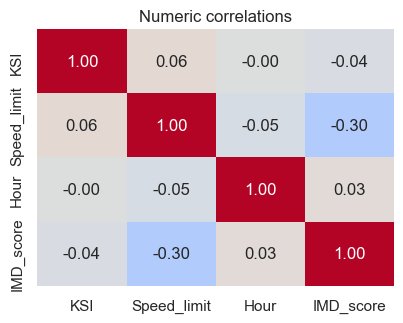

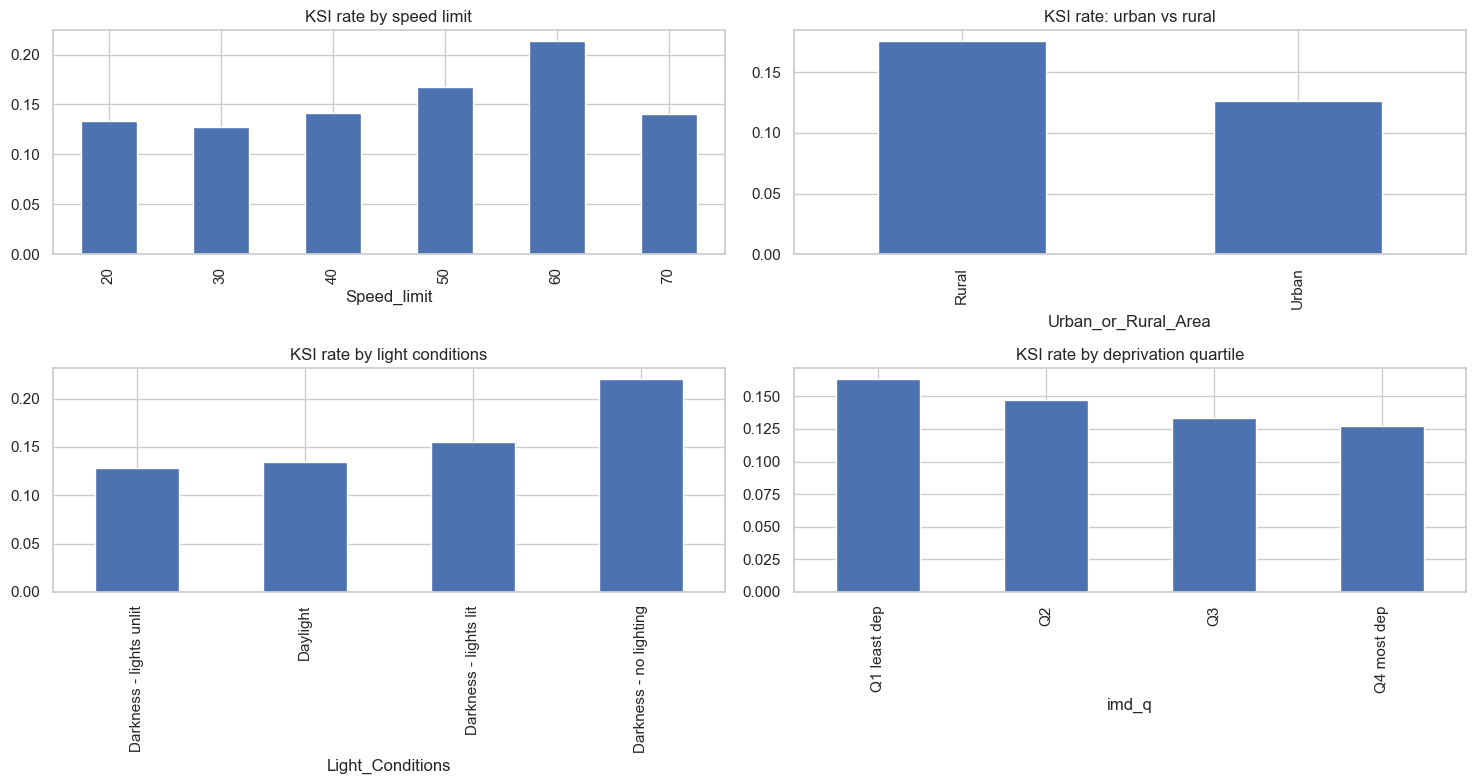

KSI rate by light condition:
 Light_Conditions
Darkness - no lighting     0.220
Darkness - lights lit      0.155
Daylight                   0.135
Darkness - lights unlit    0.129
                  n  ksi_rate  rural_share  mean_speed
imd_q                                                 
Q1 least dep  68249     0.163        0.589      44.725
Q2            67122     0.147        0.369      39.222
Q3            68501     0.133        0.236      35.798
Q4 most dep   66849     0.127        0.140      34.019


In [6]:
# numeric correlation heatmap (KSI, Speed_limit, Hour, deprivation)
num=acc[["KSI","Speed_limit","Hour",IMD_SCORE]].rename(columns={IMD_SCORE:"IMD_score"})
plt.figure(figsize=(4.2,3.4)); sns.heatmap(num.corr(),annot=True,fmt=".2f",cmap="coolwarm",center=0,cbar=False)
plt.title("Numeric correlations"); plt.tight_layout(); plt.savefig(OUTPUT/"eda_corr.png",dpi=120,bbox_inches="tight"); plt.show()
# KSI rate by the four decision-relevant contexts (speed, urban/rural, light, deprivation)
fig,ax=plt.subplots(2,2,figsize=(15,8)); ax=ax.ravel()
acc.groupby("Speed_limit").KSI.mean().plot.bar(ax=ax[0],title="KSI rate by speed limit")
acc.groupby("Urban_or_Rural_Area").KSI.mean().plot.bar(ax=ax[1],title="KSI rate: urban vs rural")
acc.groupby("Light_Conditions").KSI.mean().sort_values().plot.bar(ax=ax[2],title="KSI rate by light conditions")
acc.groupby("imd_q",observed=True).KSI.mean().plot.bar(ax=ax[3],title="KSI rate by deprivation quartile")
plt.tight_layout(); plt.savefig(OUTPUT/"eda_ksi_by_context.png",dpi=120,bbox_inches="tight"); plt.show()
print("KSI rate by light condition:\n", acc.groupby("Light_Conditions").KSI.mean().sort_values(ascending=False).round(3).to_string())
print(acc.groupby("imd_q",observed=True).agg(n=("KSI","size"),ksi_rate=("KSI","mean"),
      rural_share=("Urban_or_Rural_Area",lambda s:(s.str.lower()=="rural").mean()),mean_speed=("Speed_limit","mean")).round(3).to_string())

📊 **Read‑out (the surprise):** KSI rate rises steeply with **speed limit** and in **poor‑light / darkness** (now shown directly, bottom‑left panel + printed rates), and **falls** with deprivation (Q1 least‑deprived **16.3%** → Q4 most‑deprived **12.7%**) — the *opposite* of "poor areas suffer more". The mechanism is visible: across the same quartiles **rural share 58.9%→14.0%** and **mean speed 44.7→34.0 mph**. These are **predictive/descriptive** associations (not causal); the lighting signal **motivates the SHAP lighting/visibility reading in §11**. **→ Link:** severity tracks the **road environment**, and the deprivation story needs an **exposure** denominator (§12). / 严重度随限速/差光照升、随贫困降;为描述性非因果,光照信号引出 §11 SHAP;贫困需暴露分母 §12。

### 7.1 Descriptive map — where do collisions and severity concentrate? / 描述性地图
*A hexbin of the raw coordinates, **descriptive only**. Latitude/longitude are **not** model features (they would let the model memorise places and over‑fit — §6); this view is for human situational awareness, not prediction. No shapefile needed.*

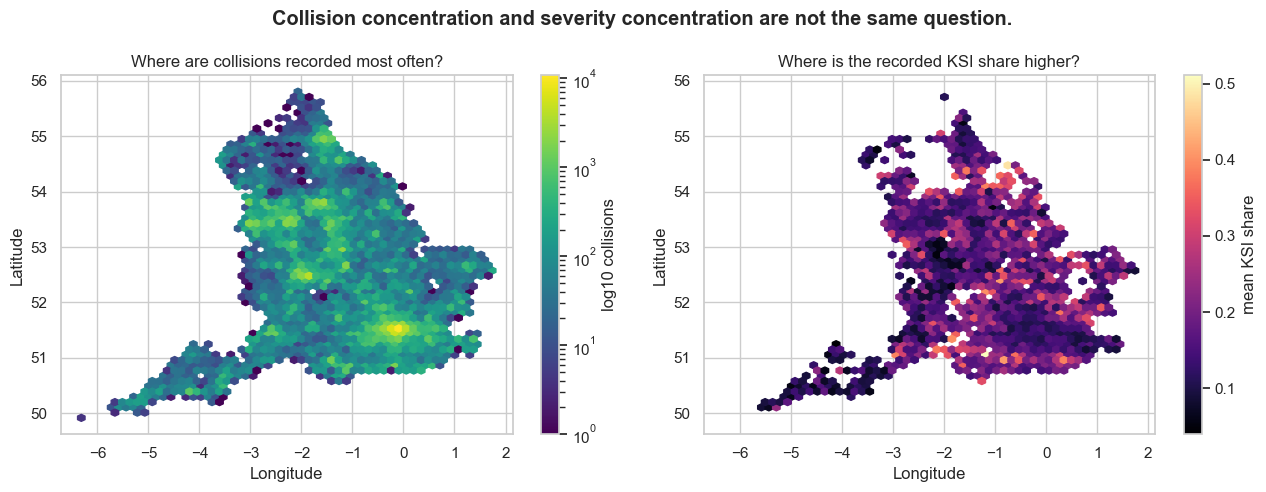

Descriptive only — coordinates are NOT predictive features (see §6 leakage control).


In [7]:
# Descriptive hexbin map (NOT predictive): collision density + mean KSI rate by location
fig,ax=plt.subplots(1,2,figsize=(13,5))
hb=ax[0].hexbin(acc.Longitude,acc.Latitude,gridsize=55,bins="log",mincnt=1,cmap="viridis")
ax[0].set_title("Where are collisions recorded most often?"); fig.colorbar(hb,ax=ax[0],label="log10 collisions")
hb2=ax[1].hexbin(acc.Longitude,acc.Latitude,C=acc.KSI,reduce_C_function=np.mean,gridsize=55,mincnt=25,cmap="magma")
ax[1].set_title("Where is the recorded KSI share higher?"); fig.colorbar(hb2,ax=ax[1],label="mean KSI share")
for a in ax: a.set_xlabel("Longitude"); a.set_ylabel("Latitude")
fig.suptitle("Collision concentration and severity concentration are not the same question.", fontweight="bold")
plt.tight_layout(); plt.savefig(OUTPUT/"map_hexbin.png",dpi=120,bbox_inches="tight"); plt.show()
print("Descriptive only — coordinates are NOT predictive features (see §6 leakage control).")

📊 **Read‑out:**
- **Descriptive only** — this map supports spatial **situational awareness**, not prediction.
- The two panels answer **different questions**: collision *density* concentrates in **urban** conurbations, but the **higher KSI‑share cells sit on sparser rural / inter‑urban areas** (echoing §7/§11: severity tracks fast rural roads).
- It does **not adjust for traffic exposure**, so dense urban areas can dominate raw counts — a misleading basis for budget allocation.
- It does **not prove causality**; latitude/longitude are used **only for visualisation**, never as predictive features (place‑memorisation risk, §6).
- **→ This motivates the next, decision‑oriented map (§12.1) that adjusts KSI burden by traffic exposure.** / 仅描述、不调暴露、非因果、坐标不入模型 → 引出 §12.1 暴露调整决策图。

## 8. Modelling Strategy
- **Outcome:** KSI vs Slight (binary). **Use case:** triage / prioritisation, not precise per‑crash prediction.
- **Validation that mirrors use:** train on **2021**, test **once** on **2022** (out‑of‑time). **GroupKFold‑by‑LAD** CV (folds split by district, so the same place can't sit in train and validation) is used as a **stability and spatial‑leakage diagnostic**; the **final benchmark is selected on the 2021 validation split** and **tested once on 2022**. (XGBoost is top on *both* the GroupKFold CV and the validation split, so the two roles agree.)
- **Imbalance:** `class_weight='balanced'` / `scale_pos_weight` (KSI ≈ 14.5%).
- **Model families (not random shopping):** interpretable **baseline** = Logistic Regression; simple non‑linear baseline = Decision Tree; course baseline = **kNN** (kept for comparison); **ensemble benchmark** = XGBoost; Random Forest is included only to *demonstrate over‑fitting*. The best **validation ROC‑AUC** model is selected and tested once on 2022.

**Model rationale — why each family is included (not random algorithm shopping):**

| Model | Why included | What it tells us |
|---|---|---|
| Logistic Regression | transparent baseline | is there a usable *linear* road‑context signal? |
| Decision Tree | simple non‑linear, rule‑based | interpretable splits / threshold‑like rules |
| kNN | distance‑based course benchmark | weak on sparse dummies — a sanity floor |
| Random Forest | bagging ensemble | tests non‑linearity & interactions; also **exposes over‑fitting** |
| XGBoost | stronger tabular benchmark | best‑in‑class for structured/tabular data |

In [8]:
dev=work.Year==2021; te=work.Year==2022
Xdev,Xte=X[dev.values],X[te.values]; ydev,yte=y[dev.values],y[te.values]
grp=work.loc[dev.values,"_lad"].values
Xtr,Xval,ytr,yval=train_test_split(Xdev,ydev,test_size=0.25,stratify=ydev,random_state=RANDOM_STATE)
# class-imbalance weight is computed from the TRAINING split only (ytr) — never the 2022 hold-out
def make():
    return {"LogReg (baseline)":Pipeline([("sc",StandardScaler(with_mean=False)),("clf",LogisticRegression(max_iter=2000,class_weight="balanced",random_state=RANDOM_STATE))]),
            "DecisionTree":DecisionTreeClassifier(max_depth=6,class_weight="balanced",random_state=RANDOM_STATE),
            "kNN":Pipeline([("sc",StandardScaler()),("clf",KNeighborsClassifier(n_neighbors=50,n_jobs=N_JOBS))]),
            "RandomForest (overfit demo)":RandomForestClassifier(n_estimators=200,n_jobs=N_JOBS,class_weight="balanced_subsample",random_state=RANDOM_STATE),
            "XGBoost (benchmark)":XGBClassifier(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.9,colsample_bytree=0.9,
                                    scale_pos_weight=(ytr==0).sum()/(ytr==1).sum(),eval_metric="aucpr",random_state=RANDOM_STATE,n_jobs=N_JOBS)}
print(f"Develop 2021 = {len(Xdev):,} (KSI {ydev.mean():.3f}) | Test 2022 = {len(Xte):,} (KSI {yte.mean():.3f}) | features {X.shape[1]}")

Develop 2021 = 138,011 (KSI 0.146) | Test 2022 = 132,710 (KSI 0.140) | features 61


## 9. Model Evaluation
Threshold‑free ranking quality (ROC‑AUC / PR‑AUC), clearly separating **CV**, **2021 validation** and **2022 out‑of‑time** performance. Accuracy is *not* used: an all‑"Slight" classifier scores ≈85.5% and looks misleadingly strong. (Threshold‑dependent precision/recall/confusion are in §10, after the cost‑based threshold.)

**Split design — the 2022 set is never used to select or tune; only for final reporting:**

| Dataset role | Data used | Purpose |
|---|---|---|
| **Training** | a 75% subset of **2021** | fit each model |
| **Validation** | held‑out 25% of 2021 (+ GroupKFold‑by‑LAD on 2021) | **select the model and tune the threshold** |
| **Test** | all of **2022** (out‑of‑time hold‑out) | **one** final evaluation — never used to select or tune |

`Raw data → cleaned England sample → 2021 development → train / validation → 2022 hold‑out test`

**The 2022 set is never used for model selection or threshold tuning; it is used only for final reporting and pre‑specified sensitivity checks (§10, §13).** So the 2022 numbers are honest deployment estimates. / 2022 绝不用于选模型/调阈值,仅用于最终报告与预先设定的敏感性检验(§10、§13)。

In [9]:
gkf=GroupKFold(n_splits=5); rows=[]
for n,m in make().items():
    cv = cross_val_score(m,Xdev,ydev,cv=gkf.split(Xdev,ydev,grp),scoring="roc_auc",n_jobs=N_JOBS).mean() if "kNN" not in n else np.nan
    m.fit(Xtr,ytr)
    tr=roc_auc_score(ytr,m.predict_proba(Xtr)[:,1]); va=roc_auc_score(yval,m.predict_proba(Xval)[:,1]); pr=average_precision_score(yval,m.predict_proba(Xval)[:,1])
    rows.append([n, round(tr,3), ("%.3f"%cv) if cv==cv else "—", round(va,3), round(tr-va,3), round(pr,3)])
res=pd.DataFrame(rows,columns=["model","Train AUC","CV AUC (GroupKFold-LAD)","2021 VAL AUC","over-fit gap (Train-VAL)","VAL PR-AUC"])
print(res.to_string(index=False))
best="XGBoost (benchmark)"
bm=make()[best].fit(Xtr,ytr)
print(f"\nSelected (best validation ROC-AUC): {best}")
print(f"2022 OUT-OF-TIME: ROC-AUC={roc_auc_score(yte,bm.predict_proba(Xte)[:,1]):.3f}  PR-AUC={average_precision_score(yte,bm.predict_proba(Xte)[:,1]):.3f}  (ROC-AUC is unchanged by calibration)")

                      model  Train AUC CV AUC (GroupKFold-LAD)  2021 VAL AUC  over-fit gap (Train-VAL)  VAL PR-AUC
          LogReg (baseline)      0.604                   0.601         0.605                    -0.001       0.209
               DecisionTree      0.605                   0.591         0.591                     0.014       0.193
                        kNN      0.654                       —         0.575                     0.078       0.187
RandomForest (overfit demo)      0.913                   0.538         0.536                     0.377       0.167
        XGBoost (benchmark)      0.661                   0.611         0.610                     0.051       0.211



Selected (best validation ROC-AUC): XGBoost (benchmark)


2022 OUT-OF-TIME: ROC-AUC=0.606  PR-AUC=0.205  (ROC-AUC is unchanged by calibration)


📊 **Read‑out:** validation ranks **XGBoost 0.610 ≈ LogReg 0.605 > DecisionTree 0.591 > kNN 0.575 ≫ RandomForest 0.537**, and CV ≈ VAL (stable). The ensemble is **not** automatically better — RandomForest **over‑fits** (≈0.54), XGBoost only just edges a plain logistic. Final **2022 out‑of‑time ROC‑AUC = 0.606** (single fit; **0.607 after calibration**, §10), **PR‑AUC = 0.205**. **Meaning:** the signal is **weak but stable** → a useful **triage / ranking** tool, **not** a precise crash‑severity predictor. / XGBoost 微胜逻辑回归、RF 过拟合;2022 AUC 0.607=弱而稳→分诊工具非精准预测。

**Random Forest as an over‑fitting diagnostic.** Random Forest reaches high **Train AUC** but weak **VAL/Test AUC** — **Train 0.913 → VAL 0.536 (over‑fit gap 0.38)** — while XGBoost (gap 0.05) and the logistic baseline (≈0) stay tight. This is expected here: the matrix has many **sparse dummy variables** and repeated local road‑context patterns, so unrestricted trees can **memorise local combinations** rather than generalisable severity signal. I therefore treat Random Forest as an **over‑fitting diagnostic, not the decision model**, and deliberately do **not** chase it with heavy tuning. / RF 训练高、验证/测试弱=过拟合(稀疏哑变量+局部模式被记忆);作为诊断而非决策模型,不重度调参。

## 10. Cost‑based Threshold Selection
**Calibrate first** (class‑weighting distorts probabilities, but a cost rule needs honest probabilities). **Cost logic:** a **false negative** = missing a serious/fatal‑risk context (costly); a **false positive** = unnecessary safety attention (cheaper). Because FN ≫ FP, the threshold should **not** default to 0.5. The **5:1** ratio below is an *illustrative policy setting*, not an objective fact — §13 sweeps 3:1–20:1.

**Important — no test‑set threshold shopping:** the operating threshold is **selected on 2021 validation probabilities**; the 2022 table is reported **only to show deployment consequences** and is **not** used to choose the threshold. / 阈值在 **2021 验证**上选;下方 2022 表仅展示部署后果,不用于选阈值。

2022 REPORTING ONLY — consequences of candidate thresholds (the threshold is SELECTED on 2021 validation, below):
 threshold  precision  recall  false_pos  false_neg  expected_cost(5:1)
      0.10      0.150   0.907      95584       1732              104244
      0.16      0.204   0.399      28959      11168               84799
      0.30      0.345   0.016        571      18295               92046
      0.50      0.000   0.000          0      18596               92980

Cost-optimal threshold (tuned on 2021 VAL, 5:1) = 0.160
              precision    recall  f1-score   support

           0      0.884     0.746     0.809    114114
           1      0.204     0.399     0.270     18596

    accuracy                          0.698    132710
   macro avg      0.544     0.573     0.540    132710
weighted avg      0.789     0.698     0.734    132710



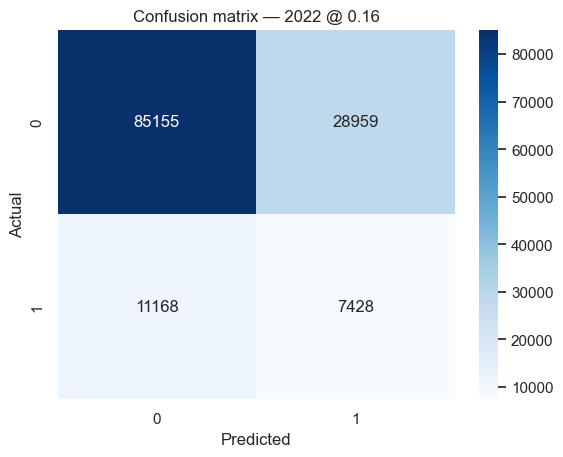

In [10]:
cal=CalibratedClassifierCV(make()[best],method="sigmoid",cv=5).fit(Xtr,ytr)
p_val=cal.predict_proba(Xval)[:,1]; p_te=cal.predict_proba(Xte)[:,1]
COST_FN,COST_FP=5.0,1.0; rows=[]
for t in [0.10,0.16,0.30,0.50]:
    pred=(p_te>=t).astype(int); tn,fp,fn,tp=confusion_matrix(yte,pred).ravel()
    rows.append([t,round(precision_score(yte,pred,zero_division=0),3),round(recall_score(yte,pred),3),fp,fn,int(fn*COST_FN+fp*COST_FP)])
print("2022 REPORTING ONLY — consequences of candidate thresholds (the threshold is SELECTED on 2021 validation, below):")
print(pd.DataFrame(rows,columns=["threshold","precision","recall","false_pos","false_neg","expected_cost(5:1)"]).to_string(index=False))
ths=np.linspace(0.05,0.95,181)
t_star=ths[int(np.argmin([confusion_matrix(yval,(p_val>=t).astype(int)).ravel()@np.array([0,COST_FP,COST_FN,0]) for t in ths]))]
pred=(p_te>=t_star).astype(int)
print(f"\nCost-optimal threshold (tuned on 2021 VAL, 5:1) = {t_star:.3f}")
print(classification_report(yte,pred,digits=3))
sns.heatmap(confusion_matrix(yte,pred),annot=True,fmt="d",cmap="Blues"); plt.title(f"Confusion matrix — 2022 @ {t_star:.2f}")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.savefig(OUTPUT/"confusion_2022.png",dpi=120,bbox_inches="tight"); plt.show()

📊 **Read‑out:** calibrated XGBoost generalises stably (VAL 0.610 → 2022 0.607). At the cost‑optimal **0.16 (5:1)**: recall ≈**0.40**, precision ≈0.20; pushing to 0.10 lifts recall to 0.91 but at ~96k false positives. → operate as a **budget‑sensitive triage** tool; the cost ratio is the policy lever (§13). / 0.16 下召回 0.40;成本比是政策旋钮。

## 11. Interpretation: Feature Importance / SHAP
**What SHAP does.** SHAP decomposes **each prediction** into additive per‑feature contributions: a **positive** SHAP value pushes that prediction **toward higher KSI risk**, a negative one toward Slight. Here SHAP is used to **translate the benchmark model into road‑safety priorities** — and to check it keys on plausible road factors. **SHAP shows *predictive contribution*, not *causal effect*.**

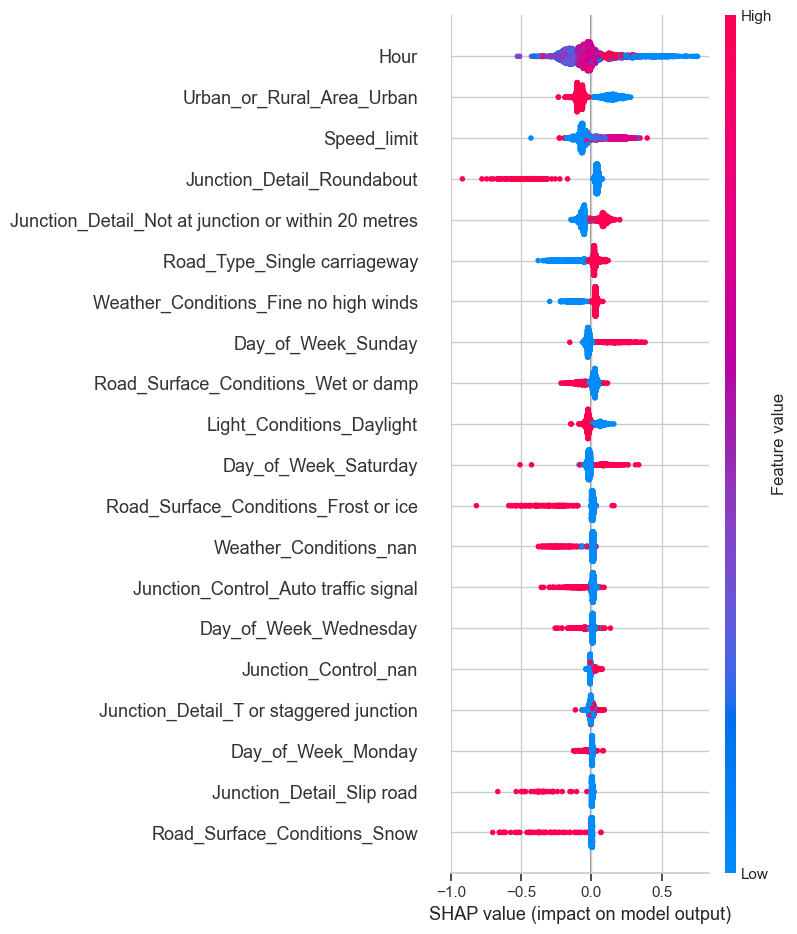

Top-10 features by mean |SHAP| (average contribution magnitude to predictions):
                                            feature  mean_abs_SHAP
                                               Hour         0.1187
                          Urban_or_Rural_Area_Urban         0.1053
                                        Speed_limit         0.0819
                         Junction_Detail_Roundabout         0.0810
Junction_Detail_Not at junction or within 20 metres         0.0688
                       Road_Type_Single carriageway         0.0539
              Weather_Conditions_Fine no high winds         0.0476
                                 Day_of_Week_Sunday         0.0390
                Road_Surface_Conditions_Wet or damp         0.0361
                          Light_Conditions_Daylight         0.0339


In [11]:
xgb=make()[best].fit(Xtr,ytr)
ex=shap.TreeExplainer(xgb); Xs=Xte.sample(min(3000,len(Xte)),random_state=RANDOM_STATE)
sv=ex.shap_values(Xs)
shap.summary_plot(sv,Xs,show=False); plt.savefig(OUTPUT/"shap_summary.png",dpi=120,bbox_inches="tight"); plt.show()
top=pd.Series(np.abs(sv).mean(axis=0),index=Xs.columns).sort_values(ascending=False).head(10).round(4).reset_index()
top.columns=["feature","mean_abs_SHAP"]
print("Top-10 features by mean |SHAP| (average contribution magnitude to predictions):")
print(top.to_string(index=False))

📊 **Top‑|SHAP| table (above):** the mean **absolute** SHAP per feature quantifies *which features move the model's predictions most, on average* — this is the **evidence base** for the business‑translation table below. Larger mean |SHAP| = larger average contribution to the predicted KSI risk. It still **does not imply causality** (predictive contribution only). / 上表按平均 |SHAP| 量化各特征对预测的平均贡献度,是下方商业转译表的证据;仍非因果。

📊 **Read‑out — top drivers → "so what" (associations, NOT causal):**

| SHAP driver | Predictive meaning | Business implication (hypothesis) |
|---|---|---|
| High **speed limit** | pushes predicted KSI risk **up** | prioritise speed management, engineering, run‑off‑road protection |
| **Rural** context | higher severity given a crash | review emergency‑response coverage, road geometry, roadside protection |
| Poor **light / darkness** | higher predicted severity | targeted lighting, visibility, night‑time interventions |
| **Road type / junction** | infrastructure risk context | review junction design / layout |
| **Vehicle type** (where relevant) | different harm profiles | targeted campaigns / enforcement focus |

The model keys on **physically plausible road‑environment** drivers (not artefacts), corroborating §7 and the §12 equity story. These are **priorities to investigate**, not proven causes. / 顶部驱动=道路环境,各转成一条干预假设(关联非因果)。

### 11.1 Unsupervised cross‑check of road‑context segments / 情境分群交叉验证
*An **outcome‑free** cross‑check: it clusters on **road context only** (`Speed_limit`, `Hour`, rural flag) and **does not use the KSI label**, testing whether a simple segmentation also surfaces a fast‑rural group. It is **not** a second model. **K=4** is a *practical* segmentation level that yields interpretable operational groups for safety teams (not a theoretically optimal K):*

| K | Practical interpretability |
|---|---|
| 3 | too coarse |
| 4 | interpretable operational groups |
| 5+ | more fragmented |

In [12]:
acc["rural_flag"]=(acc["Urban_or_Rural_Area"].str.lower()=="rural").astype(int)
S=acc[["Speed_limit","Hour","rural_flag"]].copy(); S["Hour"]=S["Hour"].fillna(S["Hour"].median()); Z=StandardScaler().fit_transform(S)
inertia=[KMeans(k,n_init=10,random_state=RANDOM_STATE).fit(Z).inertia_ for k in range(2,8)]
acc["cluster"]=KMeans(4,n_init=10,random_state=RANDOM_STATE).fit_predict(Z)
print("k-means (K=4) profile:")
print(acc.groupby("cluster").agg(n=("KSI","size"),ksi_rate=("KSI","mean"),mean_speed=("Speed_limit","mean"),rural=("rural_flag","mean")).round(2).to_string())
samp=acc.sample(5000,random_state=RANDOM_STATE).copy(); Zs=StandardScaler().fit_transform(samp[["Speed_limit","Hour","rural_flag"]].fillna(0))
samp["hc"]=AgglomerativeClustering(n_clusters=4,linkage="ward").fit_predict(Zs)
print("\nhierarchical (Ward, 5k sample) profile:")
print(samp.groupby("hc").agg(n=("KSI","size"),ksi_rate=("KSI","mean"),mean_speed=("Speed_limit","mean"),rural=("rural_flag","mean")).round(2).to_string())

k-means (K=4) profile:
              n  ksi_rate  mean_speed  rural
cluster                                     
0        110414      0.13       31.07   0.00
1         31428      0.15       33.06   1.00
2         67109      0.13       31.25   0.00
3         61770      0.19       62.24   0.96



hierarchical (Ward, 5k sample) profile:
       n  ksi_rate  mean_speed  rural
hc                                   
0   1086      0.18       62.90   0.91
1   1873      0.14       30.72   0.00
2   1331      0.12       31.06   0.00
3    710      0.16       35.96   1.00


📊 **Read‑out:** an **outcome‑free** cross‑check (no KSI label used) **also identifies a fast‑rural segment with a higher observed KSI rate** (~62–63 mph rural, KSI **0.19 / 0.18** for k‑means / hierarchical) than urban low‑speed segments (~0.12–0.14); the two methods agree, so the pattern is **not a single‑method artefact**. This **supports** the §14 prioritisation of fast rural contexts (it does not, by itself, prove anything causal). / 无监督(不用 KSI 标签)也分出高速乡村、观测 KSI 更高的一群;两法一致→非单一方法伪影,支撑 §14。

## 12. Exposure‑adjusted and Equity Analysis
"Who is worse off" has **two channels** that can point opposite ways. This is an **area‑level** analysis (not individual deprivation — **ecological‑fallacy** risk), and exposure is **motor‑vehicle** vehicle‑miles only.
- **Channel A — severity *given a recorded crash*** (KSI share by deprivation), with a cluster‑robust nested logit.
- **Channel B — *absolute* KSI burden per vehicle‑mile** (joins traffic exposure).

*The **nested** logistic specification shows whether deprivation stays associated with KSI **after** adding road‑environment controls (speed, rural); **attenuation** of the coefficient suggests the raw deprivation pattern partly reflects **different road contexts**, not deprivation alone. This **reduces, but does not eliminate, ecological‑fallacy risk** — it remains an **area‑level**, not individual‑level, statement. / 嵌套式:看控制路况后贫困是否仍相关;系数衰减=原始梯度部分由路况(而非贫困本身)解释;降低但不消除生态学谬误,仍为地区级。*

In [13]:
# Channel A: conditional severity + cluster-robust nested logit (plain language below)
print("Channel A — KSI rate (conditional severity) by deprivation quartile:")
print(acc.groupby("imd_q",observed=True).agg(n=("KSI","size"),ksi_rate=("KSI","mean")).round(3).to_string())
R=acc[["KSI",IMD_SCORE,"Speed_limit","Urban_or_Rural_Area","_lad"]].dropna().copy()
R["imd_z"]=(R[IMD_SCORE]-R[IMD_SCORE].mean())/R[IMD_SCORE].std(); R["rural"]=(R["Urban_or_Rural_Area"].str.lower()=="rural").astype(int)
print("\nDoes the deprivation effect survive controls? (cluster-robust SE by LAD; OR>1 = more KSI)")
for cols,lab in [(["imd_z"],"A: deprivation only"),(["imd_z","Speed_limit","rural"],"B: + speed + rural")]:
    m=sm.Logit(R.KSI, sm.add_constant(R[cols].astype(float))).fit(disp=0,cov_type="cluster",cov_kwds={"groups":R["_lad"]})
    print(f"   {lab:22s} deprivation OR={np.exp(m.params['imd_z']):.3f}  clustered p={m.pvalues['imd_z']:.4f}")

Channel A — KSI rate (conditional severity) by deprivation quartile:
                  n  ksi_rate
imd_q                        
Q1 least dep  68249     0.163
Q2            67122     0.147
Q3            68501     0.133
Q4 most dep   66849     0.127

Does the deprivation effect survive controls? (cluster-robust SE by LAD; OR>1 = more KSI)


   A: deprivation only    deprivation OR=0.902  clustered p=0.0000


   B: + speed + rural     deprivation OR=0.966  clustered p=0.0329


Exposure-join coverage: 259,874/270,721 (96.0%)

Channel B — per billion vehicle-miles by deprivation quartile:
               crash_per_bvm  KSI_per_bvm  KSI_share_pct
dep_q                                                  
Q1 least dep          407.1         59.4           14.6
Q2                    496.4         75.1           15.1
Q3                    704.1         94.4           13.4
Q4 most dep           738.3         91.9           12.5


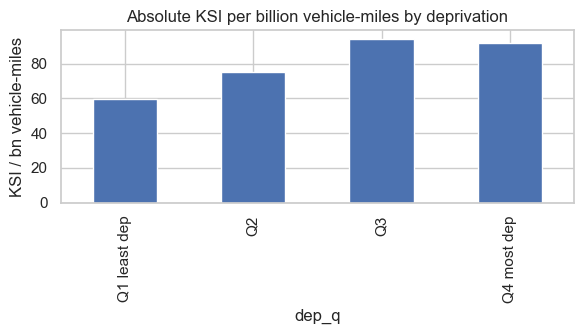

In [14]:
# Channel B: absolute KSI per billion vehicle-miles (join DfT traffic at the traffic-reporting geography)
lu=pd.read_csv(DATA/F_LAD2CTY); lu["tgt"]=lu.apply(lambda r:r.LTLA17CD if str(r.LTLA17CD)[:3] in("E06","E08","E09","W06") else r.UTLA17CD,axis=1)
acc=acc.merge(lu.assign(_n=lambda d:d.LTLA17NM.map(norm)).drop_duplicates("_n")[["_n","tgt"]],left_on="_lad",right_on="_n",how="left")
tr=pd.read_csv(DATA/F_TRAFFIC); tr=tr[tr.year.isin([2021,2022])].groupby("local_authority_code",as_index=False).all_motor_vehicles.sum()
a=acc.dropna(subset=["tgt"]).groupby("tgt").agg(crashes=("KSI","size"),ksi=("KSI","sum"),imd=(IMD_SCORE,"mean")).reset_index()
a=a.merge(tr,left_on="tgt",right_on="local_authority_code",how="inner").dropna(subset=["imd"])
cov=acc[acc.tgt.isin(a.tgt)].shape[0]; print(f"Exposure-join coverage: {cov:,}/{len(acc):,} ({cov/len(acc):.1%})")
a["dep_q"]=pd.qcut(a.imd,4,labels=["Q1 least dep","Q2","Q3","Q4 most dep"])
g=a.groupby("dep_q",observed=True).agg(tk=("ksi","sum"),tc=("crashes","sum"),tv=("all_motor_vehicles","sum"))
g["crash_per_bvm"]=(g.tc/(g.tv/1e9)).round(1); g["KSI_per_bvm"]=(g.tk/(g.tv/1e9)).round(1); g["KSI_share_pct"]=(100*g.tk/g.tc).round(1)
print("\nChannel B — per billion vehicle-miles by deprivation quartile:\n", g[["crash_per_bvm","KSI_per_bvm","KSI_share_pct"]].to_string())
g[["KSI_per_bvm"]].plot.bar(legend=False,figsize=(6,3.5),title="Absolute KSI per billion vehicle-miles by deprivation")
plt.ylabel("KSI / bn vehicle-miles"); plt.tight_layout(); plt.savefig(OUTPUT/"equity_ksi_per_vehicle_mile.png",dpi=120,bbox_inches="tight"); plt.show()

📊 **Read‑out (two channels):** **Channel A** — conditional severity is mildly **anti‑regressive** (16.3%→12.7%); under cluster‑robust SE the deprivation odds‑ratio **attenuates 0.902→0.966** once speed+rural are added (≈⅔ of it is the road environment). **Channel B** — with exposure, **crashes per vehicle‑mile rise monotonically with deprivation (407→738, ~1.8×)** and **KSI per vehicle‑mile is ~1.5× higher in the most‑deprived than the least** (Q3‑peak 94, Q4 92 vs Q1 59). **So:** severity‑given‑crash is *not* higher in deprived areas, but the **absolute KSI burden per mile is — descriptively regressive, driven by crash frequency.** Area‑level only (ecological); motor‑vehicle exposure only. / 条件严重度反累退,但每车英里绝对负担累退(频率驱动);地区级、仅机动车暴露。

### 12.1 Decision map: where is the exposure‑adjusted KSI burden highest? / 决策地图
**Why:** the hexbin above shows *where collisions happen*, but a budget‑holder needs *where serious harm is high **relative to traffic*** . This map answers **"where should a road‑safety team look first after accounting for exposure?"** **How:** reuse the §12 per‑area aggregation (traffic‑reporting geography), add each area's **accident‑centroid** longitude/latitude, and plot **bubble size = KSI count**, **colour = KSI per billion vehicle‑miles**. No shapefile / geopandas — a reproducible centroid bubble map. Areas with `<50` collisions, zero/missing exposure, or missing coordinates are excluded.

Decision map: 144 local authorities (>=50 collisions, valid exposure & coordinates)


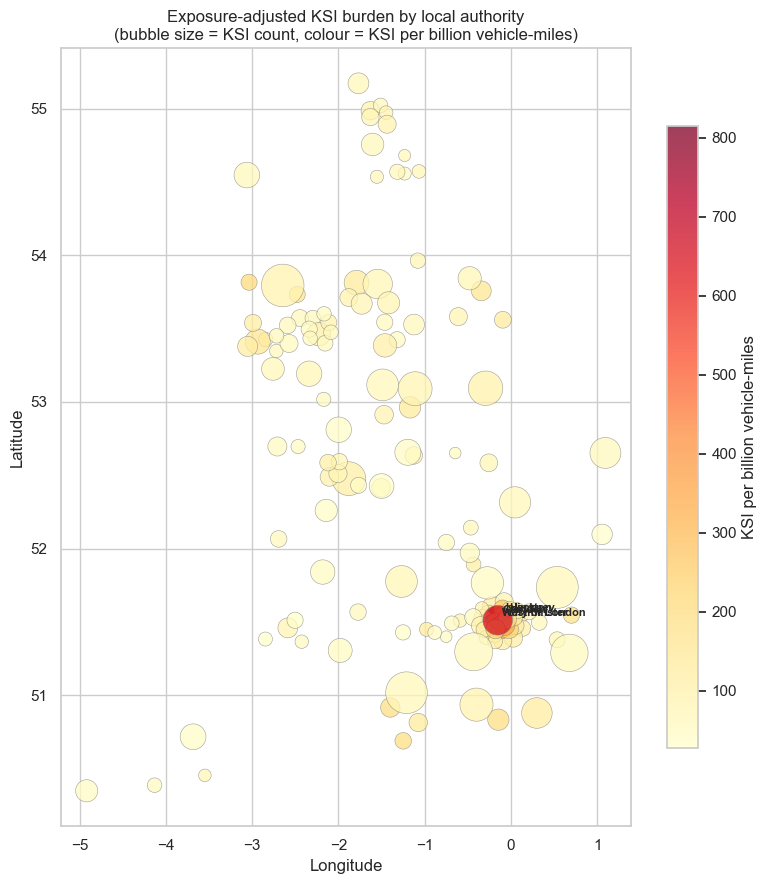


Top-10 local authorities by exposure-adjusted KSI burden:
local_authority (repr.)  KSI  collisions  veh_miles_bn  KSI_per_bvm  KSI_rate IMD_quartile
         City of London  126         635          0.15        815.5     0.198 Q1 least dep
            Westminster  576        2811          0.88        658.1     0.205           Q2
                 Camden  328        1671          0.55        599.6     0.196           Q2
                Hackney  196        1582          0.54        363.2     0.124  Q4 most dep
              Islington  158        1467          0.44        356.2     0.108           Q3
                Lambeth  313        2250          0.89        350.4     0.139           Q3
              Southwark  287        1977          0.84        339.8     0.145           Q3
 Kensington and Chelsea  185        1376          0.59        311.4     0.134           Q2
 Hammersmith and Fulham  159        1241          0.59        268.5     0.128           Q2
               Haringey  165   

In [15]:
# Build a LAD / traffic-area decision table by reusing the §12 'a' aggregation (by tgt) + adding centroids & a name
cen=(acc.dropna(subset=["Latitude","Longitude","tgt"]).groupby("tgt")
     .agg(mean_lon=("Longitude","mean"), mean_lat=("Latitude","mean"),
          name=("Local_Authority_(District)", lambda s: s.mode().iat[0] if not s.mode().empty else "NA")).reset_index())
lad=a.merge(cen,on="tgt",how="left")
lad=lad[(lad.crashes>=50) & (lad.all_motor_vehicles>0)].dropna(subset=["mean_lon","mean_lat"]).copy()  # min count, no div-by-0, valid coords
lad["ksi_rate"]=(lad.ksi/lad.crashes).round(3)
lad["KSI_per_bvm"]=(lad.ksi/(lad.all_motor_vehicles/1e9)).round(1)
lad["vm_bn"]=(lad.all_motor_vehicles/1e9).round(2)
print(f"Decision map: {len(lad)} local authorities (>=50 collisions, valid exposure & coordinates)")

# Bubble map: size = KSI count, colour = KSI per billion vehicle-miles
fig,ax=plt.subplots(figsize=(8,9))
sc=ax.scatter(lad.mean_lon,lad.mean_lat,s=40+(lad.ksi/lad.ksi.max())*900,c=lad.KSI_per_bvm,
              cmap="YlOrRd",alpha=0.75,edgecolor="grey",linewidth=0.4)
cb=fig.colorbar(sc,ax=ax,shrink=0.8); cb.set_label("KSI per billion vehicle-miles")
for _,r in lad.nlargest(5,"KSI_per_bvm").iterrows():
    ax.annotate(str(r["name"]),(r.mean_lon,r.mean_lat),fontsize=8,fontweight="bold",xytext=(3,3),textcoords="offset points")
ax.set_title("Exposure-adjusted KSI burden by local authority\n(bubble size = KSI count, colour = KSI per billion vehicle-miles)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout(); plt.savefig(OUTPUT/"map_lad_burden.png",dpi=120,bbox_inches="tight"); plt.show()

# Top-10 hotspot table -> an actionable priority list
top10=lad.sort_values("KSI_per_bvm",ascending=False).head(10)[["name","ksi","crashes","vm_bn","KSI_per_bvm","ksi_rate","dep_q"]].copy()
top10.columns=["local_authority (repr.)","KSI","collisions","veh_miles_bn","KSI_per_bvm","KSI_rate","IMD_quartile"]
print("\nTop-10 local authorities by exposure-adjusted KSI burden:")
print(top10.to_string(index=False))
print("\nNote: areas are the traffic-reporting geography (unitary/metro/London as themselves; shire districts roll up to county),")
print("labelled by a representative district name; KSI_per_bvm = KSI / (vehicle-miles / 1e9).")

In [16]:
# (Optional) Where would the 2022 triage model send teams first? REPORTING ONLY; threshold is from 2021 validation (not re-tuned on 2022)
te_df=pd.DataFrame({"_lad":work.loc[te.values,"_lad"].values,"p":p_te,"flag":(p_te>=t_star).astype(int)})
m7=te_df.groupby("_lad").agg(n_2022=("p","size"),n_flagged=("flag","sum"),mean_pred=("p","mean"))
m7=m7[m7.n_2022>=50].copy(); m7["pct_flagged"]=(100*m7.n_flagged/m7.n_2022).round(1); m7["mean_pred"]=m7.mean_pred.round(3)
print(f"Triage view (district-level, {len(m7)} LADs, >=50 2022 records; threshold {t_star:.3f} from 2021 VAL):")
print(m7.sort_values("mean_pred",ascending=False).head(8)[["n_2022","n_flagged","pct_flagged","mean_pred"]].to_string())

Triage view (district-level, 309 LADs, >=50 2022 records; threshold 0.160 from 2021 VAL):
                       n_2022  n_flagged  pct_flagged  mean_pred
_lad                                                            
craven                    186        124         66.7      0.197
rutland                    94         70         74.5      0.194
ryedale                   157        106         67.5      0.188
east northamptonshire     122         78         63.9      0.187
derbyshire dales          206        126         61.2      0.185
cotswold                  239        147         61.5      0.185
hambleton                 231        133         57.6      0.183
mendip                    262        163         62.2      0.183


📊 **Business read‑out:**
- The **hexbin map (§7.1)** answers *"where are recorded collisions / KSI shares spatially concentrated?"* — useful for awareness, but **collision density alone over‑prioritises high‑traffic urban areas**.
- The **LAD bubble map (this section)** answers the **more decision‑relevant** question: *"where is serious road harm high **relative to vehicle‑miles**?"* Because it controls for how much traffic passes through an area, **exposure‑adjusted KSI burden is the better basis for allocating a fixed budget**.
- The top‑10 table turns the picture into an **actionable priority list** (real LADs / real numbers from this sample).
- This supports the project's **two‑track** logic: **(1)** severity reduction in **high‑speed / rural** road contexts (§11); **(2)** frequency / burden reduction in **deprived or high‑exposure** areas (§12).
- **The two spatial views point to different places — this *is* the two‑track logic, made spatial:** the exposure‑adjusted burden map highlights **dense urban cores** (a *frequency* problem — e.g. central‑London boroughs), while the severity‑triage table highlights **rural districts** (high *severity‑given‑crash* — Craven, Rutland, Ryedale …). They are complementary, not contradictory.
- *Coherence note:* the single highest burden spots are **dense central‑London** boroughs (tiny vehicle‑mile denominators + many vulnerable‑user casualties); this individual‑extreme picture and the **quartile‑average regressive gradient** (§12) coexist — both point to **urban exposure / frequency** as the burden driver, not to any one deprivation tier.
- **Still descriptive, not causal** — the maps say **where to investigate and prioritise**, not which intervention will definitely cut KSI. / 气泡图按"每车英里 KSI"给可行动优先级,比纯密度更适合分配预算;支撑两轨政策;仍为描述非因果。

## 13. Robustness Checks
*Each: **Doubt → Test → Result → What changes.** (Provenance note: the official KSI‑*share* time trend rises mainly because of a severity‑**reporting** change ~2016–19 — not roads getting more dangerous — so only cross‑sectional gradients are interpreted.)*

| Doubt | Test | Result | Conclusion |
|---|---|---|---|
| `Junction_Control` missingness may distort the model | refit dropping its dummies | 2022 AUC 0.606→0.605 (≈0 change) | not driving the model |
| Threshold depends on an arbitrary cost ratio | sweep FN:FP 3:1–20:1 | recall 6%→40%→91%→100% | threshold is a **policy lever** |
| 2021–22 pattern may be a COVID artefact | official STATS19 **2015–2024** | regressive per‑mile burden persists (~1.6×) | **not** a short‑period artefact |
| LAD‑level equity may hide ecological fallacy | **LSOA‑level** IMD check | same direction, tiny effect (ρ=0.031) | risk **reduced, not eliminated** |

In [17]:
# Doubt 3 (model): does Junction_Control (~30% unknown) distort the model? refit with/without its dummies
jc=[c for c in X.columns if c.startswith("Junction_Control")]
for lab,Xc in [("with Junction_Control",X),("without Junction_Control",X.drop(columns=jc))]:
    mm=make()[best].fit(Xc.loc[Xtr.index],ytr); print(f"  {lab:24s} 2022 ROC-AUC={roc_auc_score(yte,mm.predict_proba(Xc.loc[Xte.index])[:,1]):.3f}")
# Doubt 4 (threshold): how sensitive is the operating point to the FN:FP cost ratio?
print("\ncost-ratio sensitivity (VAL-tuned threshold, 2022 recall):")
for cfn in [3,5,10,20]:
    tt=ths[int(np.argmin([confusion_matrix(yval,(p_val>=t).astype(int)).ravel()@np.array([0,1,cfn,0]) for t in ths]))]
    print(f"  FN:FP={cfn:2d}:1 -> thr={tt:.3f}, recall={recall_score(yte,(p_te>=tt).astype(int)):.3f}")

  with Junction_Control    2022 ROC-AUC=0.606


  without Junction_Control 2022 ROC-AUC=0.605

cost-ratio sensitivity (VAL-tuned threshold, 2022 recall):
  FN:FP= 3:1 -> thr=0.265, recall=0.061
  FN:FP= 5:1 -> thr=0.160, recall=0.399


  FN:FP=10:1 -> thr=0.100, recall=0.907
  FN:FP=20:1 -> thr=0.050, recall=0.998


📊 **Read‑out (Doubts 3–4):** **Doubt 3 (Junction_Control):** dropping it moves 2022 AUC by **0.001 (0.606→0.605)** → the model does **not** lean on the "unknown" artefact; conclusion unchanged. **Doubt 4 (cost ratio):** recall swings **6%→40%→91%→100%** for FN:FP 3→5→10→20:1 → the threshold is genuinely the policy lever; conclusion unchanged (only the operating point moves). / JC 不影响;阈值随成本比强变。

In [18]:
# Doubts 1-2 (official multi-year STATS19): is the regressive per-mile burden a COVID artefact? does it hold at LSOA level?
co=pd.read_csv(DATA/STATS19, usecols=["collision_year","collision_severity","local_authority_ons_district","lsoa_of_accident_location"], low_memory=False)
co=co[(co.collision_year>=2015)&(co.collision_year<=2024)].copy(); co["KSI"]=co.collision_severity.isin([1,2]).astype(int)
l2t=dict(zip(lu.LTLA17CD,lu.tgt)); co["tgt"]=co.local_authority_ons_district.map(l2t)
f10=pd.read_excel(DATA/F_IMD_LAD,sheet_name="IMD"); f10.columns=[x.strip() for x in f10.columns]
score=dict(zip(f10["Local Authority District code (2019)"],f10["IMD - Average score"]))
d2=pd.DataFrame({"lad":list(l2t)}); d2["tgt"]=d2.lad.map(l2t); d2["imd"]=d2.lad.map(score); tgt_imd=d2.groupby("tgt").imd.mean()
trf=pd.read_csv(DATA/F_TRAFFIC); trf=trf[(trf.year>=2015)&(trf.year<=2024)].groupby("local_authority_code",as_index=False).all_motor_vehicles.sum()
A=co.dropna(subset=["tgt"]).groupby("tgt").agg(crashes=("KSI","size"),ksi=("KSI","sum")).reset_index(); A["imd"]=A.tgt.map(tgt_imd)
A=A.merge(trf,left_on="tgt",right_on="local_authority_code",how="inner").dropna(subset=["imd"]); A["dep_q"]=pd.qcut(A.imd,4,labels=["Q1","Q2","Q3","Q4"])
G=A.groupby("dep_q",observed=True).agg(tk=("ksi","sum"),tv=("all_motor_vehicles","sum")); G["KSI_per_bvm"]=(G.tk/(G.tv/1e9)).round(1)
print("Doubt 1 — 2015-2024 KSI per bn vehicle-miles by deprivation:\n", G[["KSI_per_bvm"]].to_string())
f7=pd.read_csv(DATA/F_IMD_LSOA); dcol=[x for x in f7.columns if "Decile" in x and "Multiple" in x][0]; lcol=[x for x in f7.columns if x.startswith("LSOA code")][0]
co["dec"]=co.lsoa_of_accident_location.map(dict(zip(f7[lcol],f7[dcol]))); bb=co.dropna(subset=["dec"]); rho,pv=spearmanr(bb["dec"],bb["KSI"])
print(f"\nDoubt 2 — LSOA-level severity trend: Spearman rho={rho:.3f}, p={pv:.2g} (N={len(bb):,})")

Doubt 1 — 2015-2024 KSI per bn vehicle-miles by deprivation:
        KSI_per_bvm
dep_q             
Q1            62.0
Q2            75.6
Q3           102.1
Q4            97.5

Doubt 2 — LSOA-level severity trend: Spearman rho=0.031, p=9.7e-225 (N=1,047,806)


📊 **Read‑out (Doubts 1–2):** **Doubt 1 (COVID artefact?):** over **2015–2024** the regressive per‑mile burden holds — KSI/bn‑vehicle‑miles **62→102(Q3)→97.5(Q4), ~1.6×** → **not** a pandemic artefact; conclusion unchanged. **Doubt 2 (finer geography?):** at **LSOA** level the severity tilt is real in direction but **negligible in size** (Spearman ρ=**0.031**; the tiny p is only the 1.05M sample) → the §12 severity channel is small and the ecological‑fallacy worry isn't driving it; conclusion unchanged. / 频率累退非疫情假象;LSOA 严重度倾斜可忽略。

## 14. Business Implications
**Answering the three questions:** (1) road‑context gives only a **weak but stable triage signal** (2022 ROC‑AUC ≈0.61) — rank, don't predict; (2) severity is driven by the **road environment** (high speed, rural, poor light — §11); (3) the **absolute KSI burden per mile is ~1.5× higher in the most‑deprived areas**, driven by crash *frequency*, even though severity‑given‑crash is not (§12).

**Recommendations — *intervention hypotheses for safety teams to prioritise and evaluate* (each tied to a result; these are prioritisation hypotheses, NOT causal estimates of treatment effects):**
1. **Use the model as a triage / ranking tool, not a precise predictor** — justified by the modest, stable ≈0.61 AUC (§9).
2. **Prioritise high‑speed rural contexts as the leading *severity* hypothesis** — candidate levers to trial/evaluate: speed management, road design, lighting, emergency‑response — they are the top SHAP drivers and the fast‑rural cluster carries the highest KSI rate (§11).
3. **In deprived urban / high‑exposure areas, treat crash *frequency* reduction and vulnerable‑user protection as the leading hypothesis** — candidate levers to trial/evaluate: traffic calming, junction redesign, pedestrian/cyclist protection — because the absolute KSI burden per mile is highest there (§12, Channel B).
4. **Set the threshold by policy cost tolerance** — a higher FN:FP ratio raises recall but adds false positives (3:1→6% vs 10:1→91% recall, §13).
5. **Combine model scores with local engineering judgement and community knowledge** — the model ranks risk; it does not decide interventions.

### Illustrative public‑value scenario / 示例性公共价值情景
*Illustrative only — uses this notebook's own rates, not an official estimate.* Suppose a regional team reviews **10,000** recorded collision contexts. At the data's **14.5%** KSI rate, ~**1,450** involve killed‑or‑seriously‑injured outcomes. At the selected **FN:FP = 5:1** threshold the model recalls ~**40%** of KSI cases, so roughly **580** KSI‑risk contexts enter the high‑priority review pool. **If** targeted interventions there reduced KSI by just **5%**, that is ~**29** KSI outcomes avoided. Using an **illustrative** social cost of **£250,000** per serious casualty, that is ~**£7.25 million** of avoided harm before intervention costs.

This is **not** a claim that the model "saves £7.25m": it shows why even a *moderate* triage model can help **prioritise contexts where avoided harm could be material**, *if* the prioritised interventions are effective. The **£250,000 is an illustrative placeholder** — a final report should substitute official **DfT casualty valuations**. / 示例(非真实估算):1万情境→~1450 KSI→召回40%→~580 进高优先池→若干预降5%→~避免29例→按示例 £25万/重伤≈£725万;价值在"优先排序"非模型直接省钱;£25万须换官方 DfT 值。

## 15. Limitations and Future Improvements
- **Observational / descriptive, not causal.** SHAP, regression and clustering identify *predictive associations* — they do **not** prove that changing a variable reduces KSI. *Future:* combine this framework with **local intervention rollout data** (20mph zones, speed cameras, junction redesign, lighting, traffic‑calming) and estimate **causal** effects via **DID / quasi‑experimental** designs. (A DID is **not** attempted here: the data are collision‑level observational records with no defined treatment, control group, intervention timing, or pre/post panel — forcing one would be misleading.)
- **Some fields are at‑scene, not truly pre‑crash** (weather/light/surface/vehicle). *Future:* pair with ex‑ante road‑asset / speed‑camera / sensor data.
- **Kaggle extract ≠ official STATS19** (different KSI‑share basis). *Future:* rebuild end‑to‑end on the official open dataset.
- **IMD is England‑only and area‑level** (ecological fallacy). *Future:* casualty‑level / individual covariates where ethical.
- **Exposure = motor‑vehicle vehicle‑miles** (no pedestrian/cyclist). *Future:* multi‑modal exposure + AADT by road link.
- **Moderate performance (~0.61 AUC)** → prioritisation, not precise prediction. *Future:* richer context (junction geometry, traffic flow, near‑miss, collision history) + spatial models.
- **Official severity reporting changed over time.** *Future:* use DfT *adjusted* severity for any temporal claim.
- **Place/administrative joins may bias coverage.** *Future:* ONS‑code crosswalks + a published coverage waterfall (already started, §4).

### How predictive performance could be improved safely / 如何在不泄漏的前提下安全提升
**Safe directions (no leakage):**
- add **historical crash‑frequency** features — using *training‑period* history only;
- add **road geometry / class, traffic flow, speed percentiles, junction density, road‑asset** features;
- use **pedestrian/cyclist exposure** denominators, not only motor vehicle‑miles;
- tune **XGBoost** more systematically (nested CV);
- evaluate **top‑k targeting** (the team likely cares most about the riskiest 5–10% of contexts), not just global AUC;
- use **target encoding only inside cross‑validation folds** to avoid leakage.

> For road‑safety teams with **fixed budgets**, **top‑k recall** among the riskiest **5–10%** of contexts may be **more decision‑relevant than global ROC‑AUC** — it directly matches "we can only review N sites this year." / 预算固定时,最高风险 5–10% 的 **top‑k 召回**比全局 ROC‑AUC 更贴合决策。

**Explicitly forbidden (would leak / mislead):**
- using `Accident_Severity`, `Number_of_Casualties`, `Number_of_Vehicles` or any **post‑crash** variable;
- using raw **latitude/longitude** as predictive memorisation (unless spatially validated);
- selecting a model or tuning the threshold on the **2022 test set**.
/ 安全:训练期历史频率、路况几何/流量、行人骑行暴露、系统调参、top‑k 评估、CV 内 target encoding;禁止:事后变量、经纬度记忆、在 2022 上选模型/调阈值。

## 16. Reproducibility Checklist
- [x] All paths **relative** (`./data`, `./outputs`) — no machine‑specific paths.
- [x] Required input files **listed** (§0/§2) with a fail‑fast existence check (§3).
- [x] **Seed fixed** (`RANDOM_STATE=42`); **package versions printed** (below).
- [x] **Train/validation/test logic documented** (2021 dev → 2021 validation select → 2022 used only for final reporting & sensitivity, never selection/tuning; §8–§10).
- [x] **Leakage variables excluded** with a reason table (§6); data **joins report coverage** (§4, §12).
- [x] **Outputs regenerable** → figures in `./outputs/`. **No parallel noise** (`N_JOBS=1`).
- [x] **STATS19 subset provenance explained** (§2); **`requirements.txt` / `README.txt` match** the imports and data files.
- [x] **Runs top‑to‑bottom** with no red traceback (verified by a fresh Restart & Run All on the bundled `data/`).

In [19]:
import sklearn, xgboost, statsmodels, matplotlib
print("Python      ", sys.version.split()[0])
for m in [np, pd, sklearn, xgboost, shap, statsmodels, matplotlib, sns]:
    print(f"{m.__name__:12s}", getattr(m,'__version__','?'))

Python       3.13.5
numpy        2.1.3
pandas       2.2.3
sklearn      1.6.1
xgboost      3.2.0
shap         0.52.0
statsmodels  0.14.4
matplotlib   3.10.0
seaborn      0.13.2
